In [1]:
!pip show chromadb rank_bm25 ragas groq | grep -E "Name|Version"

In [2]:
!pip install -q chromadb rank_bm25 nltk "ragas==0.4.3" "langchain-community==0.3.24" "langchain-core==0.3.59" "langchain-groq==0.3.2" "langchain-openai==0.3.16"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 466.5/466.5 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 66.0 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 437.7/437.7 kB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.8/62.8 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 74.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 99.9 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 51.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.0/363.0 kB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import os
import shutil

src = '/kaggle/input/datasets/harshamin07/researchlens-dataset'
dst = '/kaggle/working/'

os.makedirs(dst, exist_ok=True)

for fname in ['bm25_index.pkl', 'bm25_metadata.pkl', 'fixed_chunks.pkl',
              'semantic_chunks.pkl', 'parsed_papers.json',
              'papers_metadata.json', 'qasper_pairs.json',
              'query_centroids.pkl']:
    src_path = os.path.join(src, fname)
    if os.path.exists(src_path):
        shutil.copy(src_path, os.path.join(dst, fname))
        print(f"  ✓ {fname}")
    else:
        print(f"  ✗ {fname} not found")

eval_q_src = '/kaggle/input/datasets/harshamin07/researchlens-eval-ques/eval_questions_v2.json'
if os.path.exists(eval_q_src):
    shutil.copy(eval_q_src, os.path.join(dst, 'eval_questions_v2.json'))
    print("  ✓ eval_questions_v2.json")
else:
    print(f"  ✗ eval_questions_v2.json not found at {eval_q_src}")

chroma_src = os.path.join(src, 'indexes', 'chroma_db')
chroma_dst = os.path.join(dst, 'chroma_db')
if os.path.exists(chroma_src) and not os.path.exists(chroma_dst):
    shutil.copytree(chroma_src, chroma_dst)
    print(f"  ✓ chroma_db/")
elif os.path.exists(os.path.join(src, 'chroma_db')) and not os.path.exists(chroma_dst):
    shutil.copytree(os.path.join(src, 'chroma_db'), chroma_dst)
    print(f"  ✓ chroma_db/ (root)")

contradiction_src = '/kaggle/input/datasets/harshamin07/researchlens-contradiction/contradiction_results.json'
if os.path.exists(contradiction_src):
    shutil.copy(contradiction_src, os.path.join(dst, 'contradiction_results.json'))
    print(f"  ✓ contradiction_results.json")

print("\nDone loading from dataset")

In [4]:
import warnings
warnings.filterwarnings('ignore')
import pickle
import json
import time
import numpy as np
import pandas as pd
from abc import ABC, abstractmethod
from typing import List, Dict, Tuple
import torch
import chromadb
from sentence_transformers import SentenceTransformer, CrossEncoder
from rank_bm25 import BM25Okapi
from transformers import AutoTokenizer, AutoModelForCausalLM
from kaggle_secrets import UserSecretsClient
from langchain_groq import ChatGroq
from ragas.llms import LangchainLLMWrapper
from ragas import evaluate, EvaluationDataset, SingleTurnSample
from ragas.metrics import (
    Faithfulness,
    ResponseRelevancy,
    LLMContextPrecisionWithoutReference
)
import nltk
nltk.download('punkt_tab', quiet=True)
nltk.download('punkt', quiet=True)
from nltk.tokenize import sent_tokenize

In [5]:
with open('/kaggle/working/bm25_index.pkl', 'rb') as f:
    bm25_index = pickle.load(f)
with open('/kaggle/working/bm25_metadata.pkl', 'rb') as f:
    bm25_metadata = pickle.load(f)

chroma_client = chromadb.PersistentClient(path='/kaggle/working/chroma_db')
fixed_collection = chroma_client.get_collection("fixed_chunks")
semantic_collection = chroma_client.get_collection("semantic_chunks")

embed_model = SentenceTransformer('all-MiniLM-L6-v2')
reranker = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2')

print(f"BM25: {len(bm25_metadata)} docs")
print(f"ChromaDB fixed: {fixed_collection.count()}")
print(f"ChromaDB semantic: {semantic_collection.count()}")
print(f"Models loaded")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

BM25: 14500 docs
ChromaDB fixed: 14500
ChromaDB semantic: 15476
Models loaded


In [6]:
model_name = "mistralai/Mistral-7B-Instruct-v0.2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
llm = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto"
)
tokenizer.pad_token = tokenizer.eos_token
print(f"Mistral loaded on: {next(llm.parameters()).device}")

config.json:   0%|          | 0.00/596 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

Mistral loaded on: cuda:0


In [7]:
secrets = UserSecretsClient()
groq_api_key = secrets.get_secret("GROQ_API_KEY")

groq_llm = ChatGroq(
    model="llama-3.1-8b-instant",
    api_key=groq_api_key,
    temperature=0
)

evaluator_llm = LangchainLLMWrapper(groq_llm)
print("Groq evaluator LLM ready")

Groq evaluator LLM ready


In [8]:
class BaseRetriever(ABC):
    @abstractmethod
    def retrieve(self, query: str, top_k: int = 5) -> List[Dict]:
        pass

    @property
    @abstractmethod
    def strategy_name(self) -> str:
        pass

    def _make_result(self, text, score, paper_id, title, chunk_id):
        return {'text': text, 'score': float(score), 'paper_id': paper_id,
                'title': title, 'chunk_id': chunk_id}

class NaiveRetriever(BaseRetriever):
    @property
    def strategy_name(self): return "naive_rag"
    def retrieve(self, query, top_k=5):
        qe = embed_model.encode(query).tolist()
        r = fixed_collection.query(query_embeddings=[qe], n_results=top_k,
                                   include=['documents', 'distances', 'metadatas'])
        return [self._make_result(d, 1-s, m['paper_id'], m['title'], m.get('chunk_id',''))
                for d, s, m in zip(r['documents'][0], r['distances'][0], r['metadatas'][0])]

class SemanticRetriever(BaseRetriever):
    @property
    def strategy_name(self): return "semantic_rag"
    def retrieve(self, query, top_k=5):
        qe = embed_model.encode(query).tolist()
        r = semantic_collection.query(query_embeddings=[qe], n_results=top_k,
                                      include=['documents', 'distances', 'metadatas'])
        return [self._make_result(d, 1-s, m['paper_id'], m['title'], m.get('chunk_id',''))
                for d, s, m in zip(r['documents'][0], r['distances'][0], r['metadatas'][0])]

class HybridRetriever(BaseRetriever):
    @property
    def strategy_name(self): return "hybrid_rag"
    def retrieve(self, query, top_k=5):
        fetch_k = top_k * 4
        qe = embed_model.encode(query).tolist()
        dr = fixed_collection.query(query_embeddings=[qe], n_results=fetch_k,
                                    include=['documents', 'distances', 'metadatas'])
        dense_hits = {}
        for rank, (d, s, m) in enumerate(zip(dr['documents'][0], dr['distances'][0], dr['metadatas'][0])):
            cid = m.get('chunk_id', f"d_{rank}")
            dense_hits[cid] = {'rank': rank, 'text': d, 'score': 1-s,
                               'paper_id': m['paper_id'], 'title': m['title']}
        bm25_scores = bm25_index.get_scores(query.lower().split())
        top_idx = np.argsort(bm25_scores)[::-1][:fetch_k]
        bm25_hits = {}
        for rank, idx in enumerate(top_idx):
            cid = bm25_metadata[idx]['chunk_id']
            bm25_hits[cid] = {'rank': rank, 'text': bm25_metadata[idx]['text'],
                              'score': bm25_scores[idx], 'paper_id': bm25_metadata[idx]['paper_id'],
                              'title': bm25_metadata[idx]['title']}
        k = 60
        all_ids = set(dense_hits) | set(bm25_hits)
        rrf = {cid: (1/(dense_hits[cid]['rank']+k) if cid in dense_hits else 0) +
                    (1/(bm25_hits[cid]['rank']+k) if cid in bm25_hits else 0)
               for cid in all_ids}
        top_ids = sorted(rrf, key=rrf.get, reverse=True)[:top_k]
        return [self._make_result(
            (dense_hits.get(cid) or bm25_hits[cid])['text'], rrf[cid],
            (dense_hits.get(cid) or bm25_hits[cid])['paper_id'],
            (dense_hits.get(cid) or bm25_hits[cid])['title'], cid)
            for cid in top_ids]

class HybridRerankerRetriever(BaseRetriever):
    @property
    def strategy_name(self): return "hybrid_rerank"
    def retrieve(self, query, top_k=5):
        candidates = HybridRetriever().retrieve(query, top_k=20)
        scores = reranker.predict([[query, c['text']] for c in candidates])
        for c, s in zip(candidates, scores):
            c['score'] = float(s)
        return sorted(candidates, key=lambda x: x['score'], reverse=True)[:top_k]

QUERY_SIGNALS = {
    'consensus': ['do papers agree', 'do researchers agree', 'is there consensus',
              'controversy', 'debate', 'conflicting', 'disagree',
              'contradiction', 'contradictory', 'dispute',
              'consistently', 'agree', 'consensus'],
    'comparative': ['compare', 'difference between', 'differ', 'versus', ' vs ',
                    'better than', 'worse than', 'advantage', 'disadvantage',
                    'trade-off', 'tradeoff', 'which is', 'contrast'],
    'procedural': ['how to', 'how do i', 'steps to', 'implement', 'build',
                   'create', 'set up', 'train', 'fine-tune', 'walkthrough'],
    'factual': ['what is', 'what are', 'define', 'definition', 'explain',
                'describe', 'who is', 'when was', 'where is', 'which paper']
}

QUERY_TO_STRATEGY = {
    'factual': 'naive_rag',
    'comparative': 'hybrid_rerank',
    'consensus': 'hybrid_rag',
    'procedural': 'semantic_rag'
}

STRATEGY_TO_RETRIEVER = {
    'naive_rag': NaiveRetriever(),
    'semantic_rag': SemanticRetriever(),
    'hybrid_rag': HybridRetriever(),
    'hybrid_rerank': HybridRerankerRetriever()
}

def keyword_classify(query):
    q = query.lower()
    for qtype, signals in QUERY_SIGNALS.items():
        for signal in signals:
            if signal in q:
                return qtype, 0.95
    return 'factual', 0.60

def route_query(query):
    qtype, confidence = keyword_classify(query)
    strategy = QUERY_TO_STRATEGY[qtype]
    return {'query_type': qtype, 'strategy': strategy,
            'confidence': confidence, 'retriever': STRATEGY_TO_RETRIEVER[strategy]}

print("All retriever and router classes defined")

All retriever and router classes defined


In [ ]:
# ── Action 2.3 — Centroid router (overrides keyword route_query above) ─────────
# Load pre-built centroids from Notebook 04. At query time: cosine distance to
# each of 4 centroids, argmax → query type. No keyword lists, no LLM fallback.
# Centroid accuracy on 50-question eval set: 82.0% vs 72.0% keyword baseline.
# Key gain: procedural routing 25% → 92% (was the primary evaluation gap).

with open('/kaggle/working/query_centroids.pkl', 'rb') as f:
    centroids = pickle.load(f)

print(f"Loaded centroids for: {list(centroids.keys())}")

def centroid_classify(query: str) -> Tuple[str, float]:
    q_emb = embed_model.encode(query, convert_to_numpy=True)
    sims = {
        qt: float(np.dot(q_emb, c) / (np.linalg.norm(q_emb) * np.linalg.norm(c)))
        for qt, c in centroids.items()
    }
    best_type = max(sims, key=sims.get)
    return best_type, round(sims[best_type], 4)

def route_query(query: str) -> Dict:
    qtype, sim = centroid_classify(query)
    strategy = QUERY_TO_STRATEGY[qtype]
    return {
        'query_type': qtype,
        'strategy':   strategy,
        'confidence': sim,
        'retriever':  STRATEGY_TO_RETRIEVER[strategy]
    }

print("route_query() → centroid_classify()  (keyword version above superseded)")

In [9]:
def build_prompt(query: str, chunks: List[Dict]) -> str:
    context = "\n\n".join([
        f"[Source: {c['title'][:60]}]\n{c['text']}"
        for c in chunks
    ])
    return f"""[INST] You are a research assistant. Answer the question using ONLY the provided context.
If the context does not contain enough information, say "I don't have enough information."
Be concise. Maximum 3 sentences.

Context:
{context}

Question: {query} [/INST]"""

def generate_answer(query: str, chunks: List[Dict], max_new_tokens: int = 150) -> str:
    prompt = build_prompt(query, chunks)
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True,
                       max_length=3000).to(llm.device)
    with torch.no_grad():
        outputs = llm.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=0.1,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id
        )
    return tokenizer.decode(
        outputs[0][inputs['input_ids'].shape[1]:],
        skip_special_tokens=True
    ).strip()

def generate_batch_v2(prompts, max_new_tokens=150, temperature=0.1, batch_size=4):
    """
    Batched replacement for the per-question generate_answer() loop in Cell 9.
    batch_size=4 with max_length=2048 fits Mistral-7B fp16 in T4's 16GB.
    Drop to batch_size=2 if you hit OOM.
    """
    tokenizer.padding_side = 'left'
    answers = []
    for start in range(0, len(prompts), batch_size):
        batch = prompts[start : start + batch_size]
        enc = tokenizer(batch, return_tensors='pt', padding=True,
                        truncation=True, max_length=2048).to(llm.device)
        plen = enc.input_ids.shape[1]
        with torch.no_grad():
            out = llm.generate(**enc, max_new_tokens=max_new_tokens,
                               temperature=temperature, do_sample=True,
                               pad_token_id=tokenizer.eos_token_id)
        decoded = tokenizer.batch_decode(out[:, plen:], skip_special_tokens=True)
        answers.extend(a.strip() for a in decoded)
        del enc, out
        torch.cuda.empty_cache()
        print(f"  {min(start + batch_size, len(prompts))}/{len(prompts)}", end='\r')
    print()
    return answers

print("generate_batch_v2() defined  |  batch_size=4, max_new_tokens=150, max_length=2048")

print("Generation function defined")

generate_batch_v2() defined  |  batch_size=4, max_new_tokens=150, max_length=2048
Generation function defined


In [10]:
with open('/kaggle/working/eval_questions_v2.json', 'r') as f:
    eval_data = json.load(f)

scoring_cfg   = eval_data['scoring_config']
eval_questions = eval_data['questions']

from collections import Counter
type_dist = Counter(q['query_type'] for q in eval_questions)
print(f"Loaded {len(eval_questions)} questions: {dict(type_dist)}")
print(f"Scoring thresholds: {scoring_cfg['thresholds']}\n")

strategies = [
    NaiveRetriever(),
    SemanticRetriever(),
    HybridRetriever(),
    HybridRerankerRetriever()
]

strategy_results   = {s.strategy_name: [] for s in strategies}
strategy_latencies = {s.strategy_name: [] for s in strategies}

print("Running batched evaluation (estimate: ~10 min per strategy on T4)...\n")

for strategy in strategies:
    print(f"Strategy: {strategy.strategy_name}")
    t0 = time.time()

    all_chunks = [strategy.retrieve(q['question'], top_k=5) for q in eval_questions]
    print(f"  Retrieval: {time.time()-t0:.0f}s")

    prompts = [build_prompt(q['question'], chunks)
               for q, chunks in zip(eval_questions, all_chunks)]

    t1 = time.time()
    answers = generate_batch_v2(prompts)
    gen_time = time.time() - t1
    print(f"  Generation: {gen_time:.0f}s  ({gen_time/len(prompts):.1f}s per question)")

    per_q_latency = (time.time() - t0) / len(eval_questions)
    strategy_latencies[strategy.strategy_name] = [per_q_latency] * len(eval_questions)

    for q, chunks, answer in zip(eval_questions, all_chunks, answers):
        strategy_results[strategy.strategy_name].append({
            'user_input':         q['question'],
            'response':           answer,
            'retrieved_contexts': [c['text'] for c in chunks],
            'reference':          q['reference_answer'],
            'query_type':         q['query_type'],
            'source_papers':      q['source_papers'],
        })

    print(f"  Done\n")

print(f"Total: {len(eval_questions) * len(strategies)} answers generated.")


Loaded 50 questions: {'factual': 13, 'comparative': 13, 'consensus': 12, 'procedural': 12}
Scoring thresholds: {'factual': 0.55, 'comparative': 0.55, 'procedural': 0.55, 'consensus': 0.45}

Running batched evaluation (estimate: ~10 min per strategy on T4)...

Strategy: naive_rag
  Retrieval: 1s
  50/50
  Generation: 482s  (9.6s per question)
  Done

Strategy: semantic_rag
  Retrieval: 1s
  50/50
  Generation: 476s  (9.5s per question)
  Done

Strategy: hybrid_rag
  Retrieval: 6s
  50/50
  Generation: 568s  (11.4s per question)
  Done

Strategy: hybrid_rerank
  Retrieval: 15s
  50/50
  Generation: 588s  (11.8s per question)
  Done

Total: 200 answers generated.


In [11]:
import re
from sklearn.metrics.pairwise import cosine_similarity as sklearn_cosine

def compute_faithfulness(answer: str, chunks: List[Dict]) -> float:
    if not answer or "don't have enough information" in answer.lower():
        return 0.0
    context_text = ' '.join([c['text'] for c in chunks])
    context_words = set(re.sub(r'[^\w\s]', '', context_text.lower()).split())
    answer_words = set(re.sub(r'[^\w\s]', '', answer.lower()).split())
    stopwords = {'the','a','an','is','are','was','were','in','on','at','to',
                 'for','of','and','or','but','it','this','that','be','have',
                 'has','had','with','from','by','as','we','our','their','its'}
    content_words = answer_words - stopwords
    if not content_words:
        return 0.0
    return len(content_words & context_words) / len(content_words)

def compute_context_precision(query: str, chunks: List[Dict]) -> float:
    query_emb = embed_model.encode(query, convert_to_numpy=True)
    chunk_embs = embed_model.encode([c['text'] for c in chunks], convert_to_numpy=True)
    sims = sklearn_cosine([query_emb], chunk_embs)[0]
    relevant = sum(1 for s in sims if s > 0.4)
    return relevant / len(chunks) if chunks else 0.0

def compute_answer_relevance(query: str, answer: str) -> float:
    if not answer or "don't have enough information" in answer.lower():
        return 0.0
    query_emb = embed_model.encode(query, convert_to_numpy=True)
    answer_emb = embed_model.encode(answer, convert_to_numpy=True)
    return float(sklearn_cosine([query_emb], [answer_emb])[0][0])

ragas_scores = {}

for strategy_name, results in strategy_results.items():
    print(f"Evaluating {strategy_name}...")
    
    faithfulness_scores = []
    precision_scores = []
    relevance_scores = []
    
    for r in results:
        chunks = [{'text': t} for t in r['retrieved_contexts']]
        faithfulness_scores.append(compute_faithfulness(r['response'], chunks))
        precision_scores.append(compute_context_precision(r['user_input'], chunks))
        relevance_scores.append(compute_answer_relevance(r['user_input'], r['response']))
    
    ragas_scores[strategy_name] = {
        'faithfulness': round(np.mean(faithfulness_scores), 3),
        'context_precision': round(np.mean(precision_scores), 3),
        'answer_relevance': round(np.mean(relevance_scores), 3),
        'avg_latency_ms': round(np.mean(strategy_latencies[strategy_name]) * 1000)
    }
    
    print(f"  ✓ faithfulness={ragas_scores[strategy_name]['faithfulness']} | "
          f"precision={ragas_scores[strategy_name]['context_precision']} | "
          f"relevance={ragas_scores[strategy_name]['answer_relevance']} | "
          f"latency={ragas_scores[strategy_name]['avg_latency_ms']}ms")

# --- Correctness scoring (sentence_mean_of_max_cosine from scoring_config) ---

def sentence_mean_of_max(ref, gen):
    rs = [s for s in sent_tokenize(ref) if len(s.strip()) > 10]
    gs = [s for s in sent_tokenize(gen) if len(s.strip()) > 10]
    if not rs or not gs:
        return 0.0
    ref_embs = embed_model.encode(rs, batch_size=32, show_progress_bar=False)
    gen_embs = embed_model.encode(gs, batch_size=32, show_progress_bar=False)
    return float(sklearn_cosine(ref_embs, gen_embs).max(axis=1).mean())

thresholds = scoring_cfg['thresholds']

for strategy_name, results in strategy_results.items():
    scores, binaries = [], []
    for r in results:
        s = sentence_mean_of_max(r['reference'], r['response'])
        thr = thresholds[r['query_type']]
        r['correctness_score']  = round(s, 4)
        r['correctness_binary'] = int(s >= thr)
        scores.append(s); binaries.append(r['correctness_binary'])
    ragas_scores[strategy_name]['correctness_score'] = round(np.mean(scores), 3)
    ragas_scores[strategy_name]['pct_correct']       = round(100 * np.mean(binaries), 1)
    print(f"{strategy_name}: correctness={ragas_scores[strategy_name]['correctness_score']}  "
          f"correct={ragas_scores[strategy_name]['pct_correct']}%")

print("\nDone.")

Evaluating naive_rag...
  ✓ faithfulness=0.718 | precision=1.0 | relevance=0.549 | latency=9669ms
Evaluating semantic_rag...
  ✓ faithfulness=0.716 | precision=1.0 | relevance=0.556 | latency=9525ms
Evaluating hybrid_rag...
  ✓ faithfulness=0.811 | precision=0.876 | relevance=0.525 | latency=11494ms
Evaluating hybrid_rerank...
  ✓ faithfulness=0.833 | precision=0.888 | relevance=0.53 | latency=12047ms
naive_rag: correctness=0.483  correct=40.0%
semantic_rag: correctness=0.504  correct=50.0%
hybrid_rag: correctness=0.515  correct=56.0%
hybrid_rerank: correctness=0.527  correct=64.0%

Done.


In [12]:
print("Evaluating adaptive router (batched)...")
t0 = time.time()

routing_info = [route_query(q['question']) for q in eval_questions]
all_chunks   = [ri['retriever'].retrieve(q['question'], top_k=5)
                for ri, q in zip(routing_info, eval_questions)]
prompts      = [build_prompt(q['question'], chunks)
                for q, chunks in zip(eval_questions, all_chunks)]

router_latencies = []
t1 = time.time()
router_answers = generate_batch_v2(prompts)
gen_time = time.time() - t1
total_time = time.time() - t0
per_q = total_time / len(eval_questions)
router_latencies = [per_q] * len(eval_questions)
print(f"Generation: {gen_time:.0f}s  ({gen_time/len(eval_questions):.1f}s per question)")

router_results = []
router_strategy_counts = {}
for q, ri, chunks, answer in zip(eval_questions, routing_info, all_chunks, router_answers):
    router_results.append({
        'user_input':         q['question'],
        'response':           answer,
        'retrieved_contexts': [c['text'] for c in chunks],
        'reference':          q['reference_answer'],
        'query_type':         q['query_type'],
        'predicted_type':     ri['query_type'],
        'strategy_used':      ri['strategy'],
    })
    s = ri['strategy']
    router_strategy_counts[s] = router_strategy_counts.get(s, 0) + 1

faithfulness_scores, precision_scores, relevance_scores = [], [], []
for r in router_results:
    chunks_dicts = [{'text': t} for t in r['retrieved_contexts']]
    faithfulness_scores.append(compute_faithfulness(r['response'], chunks_dicts))
    precision_scores.append(compute_context_precision(r['user_input'], chunks_dicts))
    relevance_scores.append(compute_answer_relevance(r['user_input'], r['response']))

# confidence score per question (3 signals, existing weights 0.4/0.3/0.3)
import math

_RRF_MAX = 2 / 61
for r, chunks, faith, relev in zip(router_results, all_chunks,
                                    faithfulness_scores, relevance_scores):
    ret_raw = float(np.mean([c['score'] for c in chunks])) if chunks else 0.0

    if r['strategy_used'] == 'hybrid_rerank':
        ret_norm = 1 / (1 + math.exp(-ret_raw))   # sigmoid: cross-encoder logit → [0,1]
    elif ret_raw < 0.05:
        ret_norm = min(1.0, ret_raw / _RRF_MAX)    # RRF scale → [0,1]
    else:
        ret_norm = min(1.0, max(0.0, ret_raw))     # cosine similarity: already [0,1]

    conf = 0.4 * ret_norm + 0.3 * faith + 0.3 * relev
    r['confidence'] = round(conf * 100, 1)

# correctness
corr_scores, corr_bin = [], []
for r in router_results:
    s = sentence_mean_of_max(r['reference'], r['response'])
    thr = thresholds[r['query_type']]
    r['correctness_score']  = round(s, 4)
    r['correctness_binary'] = int(s >= thr)
    corr_scores.append(s); corr_bin.append(r['correctness_binary'])

router_accuracy = np.mean([
    int(r['predicted_type'] == r['query_type']) for r in router_results
])

ragas_scores['adaptive_router'] = {
    'faithfulness':      round(np.mean(faithfulness_scores), 3),
    'context_precision': round(np.mean(precision_scores), 3),
    'answer_relevance':  round(np.mean(relevance_scores), 3),
    'avg_latency_ms':    round(np.mean(router_latencies) * 1000),
    'correctness_score': round(np.mean(corr_scores), 3),
    'pct_correct':       round(100 * np.mean(corr_bin), 1),
}

print(f"\nAdaptive router:")
print(f"  faithfulness={ragas_scores['adaptive_router']['faithfulness']} | "
      f"correctness={ragas_scores['adaptive_router']['correctness_score']} | "
      f"latency={ragas_scores['adaptive_router']['avg_latency_ms']}ms")
print(f"  Strategy distribution: {router_strategy_counts}")
print(f"  Router accuracy (predicted vs true type): {router_accuracy*100:.1f}%")


Evaluating adaptive router (batched)...
  50/50
Generation: 550s  (11.0s per question)

Adaptive router:
  faithfulness=0.785 | correctness=0.504 | latency=11133ms
  Strategy distribution: {'naive_rag': 16, 'hybrid_rerank': 19, 'hybrid_rag': 12, 'semantic_rag': 3}
  Router accuracy (predicted vs true type): 72.0%


In [13]:
rows = []
display_names = {
    'naive_rag': 'A · Naive RAG',
    'semantic_rag': 'B · Semantic RAG',
    'hybrid_rag': 'C · Hybrid RAG',
    'hybrid_rerank': 'D · Hybrid + Reranker',
    'adaptive_router': 'Adaptive Router'
}

for strategy_name, scores in ragas_scores.items():
    if 'error' in scores:
        continue
    rows.append({
        'Strategy': display_names.get(strategy_name, strategy_name),
        'Faithfulness': scores['faithfulness'],
        'Context Precision': scores['context_precision'],
        'Answer Relevance': scores['answer_relevance'],
        'Correctness':       scores.get('correctness_score', '-'),
        '% Correct':         scores.get('pct_correct', '-'),
        'Avg Latency (ms)': scores['avg_latency_ms']
    })

results_df = pd.DataFrame(rows).set_index('Strategy')

print("\n" + "="*85)
print("RESEARCHLENS — STRATEGY COMPARISON TABLE")
print("="*85)
print(results_df.to_string())
print("="*85)
print(f"\nEval set: type-balanced (factual=13, comparative=13, consensus=12, procedural=12)")
print(f"Correctness: sentence_mean_of_max_cosine vs reference answer (thresholds 0.55/0.45)")
print(f"Generator:   Mistral-7B-Instruct-v0.2")


RESEARCHLENS — STRATEGY COMPARISON TABLE
                       Faithfulness  Context Precision  Answer Relevance  Correctness  % Correct  Avg Latency (ms)
Strategy                                                                                                          
A · Naive RAG                 0.718              1.000             0.549        0.483       40.0              9669
B · Semantic RAG              0.716              1.000             0.556        0.504       50.0              9525
C · Hybrid RAG                0.811              0.876             0.525        0.515       56.0             11494
D · Hybrid + Reranker         0.833              0.888             0.530        0.527       64.0             12047
Adaptive Router               0.785              0.892             0.509        0.504       60.0             11133

Eval set: type-balanced (factual=13, comparative=13, consensus=12, procedural=12)
Correctness: sentence_mean_of_max_cosine vs reference answer (threshol

In [14]:
print("CUSTOM METRICS SUMMARY")
print("-"*50)
print(f"Routing Accuracy (type-balanced set): {router_accuracy*100:.1f}%")
print(f"  (vs 100% on 40-query keyword-matched test set — Notebook 04)")
print(f"  Strategy distribution: {router_strategy_counts}")

valid_scores = {k: v for k, v in ragas_scores.items() if 'error' not in v and k != 'adaptive_router'}
best_faith_strategy = max(valid_scores, key=lambda x: valid_scores[x]['faithfulness'])
naive_faith = ragas_scores['naive_rag']['faithfulness']
best_faith = ragas_scores[best_faith_strategy]['faithfulness']

if naive_faith > 0:
    improvement = ((best_faith - naive_faith) / naive_faith) * 100
    print(f"Best Faithfulness:    {best_faith} ({display_names[best_faith_strategy]})")
    print(f"Improvement vs Naive: +{improvement:.1f}%")

naive_lat = ragas_scores['naive_rag']['avg_latency_ms']
rerank_lat = ragas_scores['hybrid_rerank']['avg_latency_ms']
overhead = ((rerank_lat - naive_lat) / naive_lat) * 100
print(f"Reranker overhead:    +{overhead:.0f}% latency vs Naive")
print(f"Router distribution:  {router_strategy_counts}")

best_corr = max(valid_scores, key=lambda x: valid_scores[x].get('correctness_score', 0))
print(f"\nBest Correctness:     {ragas_scores[best_corr]['correctness_score']} ({display_names[best_corr]})")
print(f"Adaptive Correctness: {ragas_scores['adaptive_router']['correctness_score']}"
      f"  ({ragas_scores['adaptive_router']['pct_correct']}% questions answered correctly)")

CUSTOM METRICS SUMMARY
--------------------------------------------------
Routing Accuracy (type-balanced set): 72.0%
  (vs 100% on 40-query keyword-matched test set — Notebook 04)
  Strategy distribution: {'naive_rag': 16, 'hybrid_rerank': 19, 'hybrid_rag': 12, 'semantic_rag': 3}
Best Faithfulness:    0.833 (D · Hybrid + Reranker)
Improvement vs Naive: +16.0%
Reranker overhead:    +25% latency vs Naive
Router distribution:  {'naive_rag': 16, 'hybrid_rerank': 19, 'hybrid_rag': 12, 'semantic_rag': 3}

Best Correctness:     0.527 (D · Hybrid + Reranker)
Adaptive Correctness: 0.504  (60.0% questions answered correctly)


In [15]:
results_df.to_csv('/kaggle/working/comparison_table.csv')

full_results = {
    'eval_set': 'eval_questions_v2',
    'ragas_scores': ragas_scores,
    'strategy_latencies': {k: [round(v*1000) for v in vals]
                           for k, vals in strategy_latencies.items()},
    'router_strategy_distribution': router_strategy_counts,
    'router_accuracy_on_balanced_set': round(router_accuracy, 4),
    'eval_size': len(eval_questions),
    'scoring_config': scoring_cfg,
    'metrics': 'faithfulness=token overlap | precision=embedding cosine | '
               'relevance=query-answer cosine | correctness=sentence_mean_of_max_cosine',
    'generator': 'Mistral-7B-Instruct-v0.2',
    'per_query_results': {
        'adaptive_router': router_results,
        **{s: strategy_results[s] for s in strategy_results}
    },
    'summary': {
        'best_faithfulness':           max(v['faithfulness'] for v in ragas_scores.values()),
        'best_correctness':            max(v.get('correctness_score', 0) for v in ragas_scores.values()),
        'adaptive_correctness_score':  ragas_scores['adaptive_router']['correctness_score'],
        'adaptive_pct_correct':        ragas_scores['adaptive_router']['pct_correct'],
        'router_accuracy':             round(router_accuracy * 100, 1),
        'reranker_latency_overhead':   f"{overhead:.0f}%",
    }
}

with open('/kaggle/working/full_eval_results.json', 'w') as f:
    json.dump(full_results, f, indent=2)

print("Saved:")
print("  ✓ comparison_table.csv")
print("  ✓ full_eval_results.json")
print("\nDownload full_eval_results.json — it's the input for Action 1.1 (calibration plot).")
print("The per_query_results.adaptive_router array has confidence + correctness per question.")
print("\n=== Notebook 07 v2 Complete ===")
print(results_df.to_string())

Saved:
  ✓ comparison_table.csv
  ✓ full_eval_results.json

Download full_eval_results.json — it's the input for Action 1.1 (calibration plot).
The per_query_results.adaptive_router array has confidence + correctness per question.

=== Notebook 07 v2 Complete ===
                       Faithfulness  Context Precision  Answer Relevance  Correctness  % Correct  Avg Latency (ms)
Strategy                                                                                                          
A · Naive RAG                 0.718              1.000             0.549        0.483       40.0              9669
B · Semantic RAG              0.716              1.000             0.556        0.504       50.0              9525
C · Hybrid RAG                0.811              0.876             0.525        0.515       56.0             11494
D · Hybrid + Reranker         0.833              0.888             0.530        0.527       64.0             12047
Adaptive Router               0.785           

In [16]:
import os

src = '/kaggle/input/datasets/harshamin07/researchlens-dataset'

files = ['bm25_index.pkl', 'bm25_metadata.pkl', 'fixed_chunks.pkl', 'semantic_chunks.pkl']
for f in files:
    path = os.path.join(src, f)
    if os.path.exists(path):
        size = os.path.getsize(path) / (1024*1024)
        print(f"{f}: {size:.1f} MB")

chroma_size = sum(
    os.path.getsize(os.path.join(root, file))
    for root, dirs, files_list in os.walk(os.path.join(src, 'chroma_db'))
    for file in files_list
) / (1024*1024)
print(f"chroma_db/: {chroma_size:.1f} MB")

indexes_size = sum(
    os.path.getsize(os.path.join(root, file))
    for root, dirs, files_list in os.walk(os.path.join(src, 'indexes'))
    for file in files_list
) / (1024*1024)
print(f"indexes/: {indexes_size:.1f} MB")

bm25_index.pkl: 37.2 MB
bm25_metadata.pkl: 33.7 MB
fixed_chunks.pkl: 33.8 MB
semantic_chunks.pkl: 31.8 MB
chroma_db/: 533.5 MB
indexes/: 0.0 MB


In [1]:
import json
import numpy as np
from collections import Counter
from sklearn.metrics import roc_auc_score, roc_curve

# ── Load ──────────────────────────────────────────────────────────────────────
with open('/kaggle/input/datasets/harshamin07/reasearchlens-eval-results/full_eval_results.json') as f:
    full_results = json.load(f)

records = full_results['per_query_results']['adaptive_router']
print(f"Loaded {len(records)} adaptive-router records")
print(f"Keys: {list(records[0].keys())}\n")

confidences     = np.array([r['confidence']         for r in records])  # 0–100
correctness     = np.array([r['correctness_score']  for r in records])  # 0–1 float
binary          = np.array([r['correctness_binary'] for r in records], dtype=int)
query_types     = [r['query_type']    for r in records]
strategies_used = [r['strategy_used'] for r in records]

# ── Confidence bands ───────────────────────────────────────────────────────────
def band_label(c):
    return 'GREEN' if c >= 80 else ('YELLOW' if c >= 50 else 'RED')

bands = [band_label(c) for c in confidences]

per_band = {}
for b in ['GREEN', 'YELLOW', 'RED']:
    idx = [i for i, x in enumerate(bands) if x == b]
    n   = len(idx)
    per_band[b] = {
        'count':            n,
        'mean_correctness': float(correctness[idx].mean())  if n else None,
        'pct_correct':      float(binary[idx].mean() * 100) if n else None,
        'conf_range':       [float(confidences[idx].min()),
                             float(confidences[idx].max())] if n else None,
    }

# ── ROC-AUC ───────────────────────────────────────────────────────────────────
n_pos, n_neg = int(binary.sum()), int((1 - binary).sum())
if n_pos > 0 and n_neg > 0:
    auc         = roc_auc_score(binary, confidences / 100)
    fpr, tpr, _ = roc_curve(binary, confidences / 100)
else:
    auc      = float('nan')
    fpr, tpr = np.array([0., 1.]), np.array([0., 1.])

# ── Per query-type breakdown ───────────────────────────────────────────────────
type_stats = {}
for qt in ['factual', 'comparative', 'consensus', 'procedural']:
    idx = [i for i, t in enumerate(query_types) if t == qt]
    if not idx:
        continue
    c_arr = confidences[idx]; r_arr = correctness[idx]; b_arr = binary[idx]
    type_stats[qt] = {
        'count':            len(idx),
        'mean_confidence':  float(c_arr.mean()),
        'mean_correctness': float(r_arr.mean()),
        'pct_correct':      float(b_arr.mean() * 100),
        'band_dist':        Counter(band_label(c) for c in c_arr),
        'strategy_dist':    dict(Counter(strategies_used[i] for i in idx)),
    }

# ── Print honest summary ───────────────────────────────────────────────────────
print("=" * 62)
print("  CALIBRATION ANALYSIS — ResearchLens  (Action 1.1)")
print("=" * 62)

print(f"\nOverall  |  n={len(records)}  "
      f"mean_correctness={correctness.mean():.3f}  "
      f"pct_correct={binary.mean()*100:.0f}%")
print(f"Confidence  min={confidences.min():.1f}  "
      f"max={confidences.max():.1f}  "
      f"mean={confidences.mean():.1f}")

print(f"\nROC-AUC: {auc:.3f}  (random baseline = 0.500)")
if np.isnan(auc):
    print("  ✗ AUC undefined — all binary labels are the same class.")
elif auc >= 0.70:
    print("  ✓ AUC ≥ 0.70 — confidence score meaningfully discriminates correct answers.")
else:
    print("  ✗ AUC < 0.70 — confidence score does NOT reliably discriminate correct answers.")
    print("    This is expected for hand-picked weights (0.4/0.3/0.3).")
    print("    → Motivates Action 2.1: logistic-regression confidence combiner.")

print(f"\n{'Band':<8}  {'N':>4}  {'MeanCorr':>9}  {'%Correct':>10}  ConfRange")
print("-" * 50)
for b in ['GREEN', 'YELLOW', 'RED']:
    s = per_band[b]
    if s['count'] == 0:
        print(f"{b:<8}  {s['count']:>4}  — no questions in this band")
        continue
    cr = s['conf_range']
    print(f"{b:<8}  {s['count']:>4}  {s['mean_correctness']:>9.3f}  "
          f"{s['pct_correct']:>9.1f}%  [{cr[0]:.1f}, {cr[1]:.1f}]")

g_pct = per_band['GREEN']['pct_correct']
r_pct = per_band['RED']['pct_correct']
if g_pct is not None and r_pct is not None:
    delta = g_pct - r_pct
    note  = "meaningful separation" if abs(delta) >= 10 else "weak separation — confidence bands not useful"
    print(f"\nGREEN vs RED gap: {delta:+.1f}pp  ({note})")
elif per_band['RED']['count'] == 0:
    print("\nNo RED-band questions — all confidence scores ≥ 50.")

print(f"\n{'Type':<14}  {'N':>3}  {'MeanConf':>9}  {'MeanCorr':>9}  {'%Corr':>6}  G/Y/R")
print("-" * 58)
for qt, s in type_stats.items():
    bd   = s['band_dist']
    strs = ', '.join(f"{k}:{v}" for k, v in sorted(s['strategy_dist'].items()))
    print(f"{qt:<14}  {s['count']:>3}  {s['mean_confidence']:>9.1f}  "
          f"{s['mean_correctness']:>9.3f}  {s['pct_correct']:>5.0f}%  "
          f"{bd.get('GREEN',0)}/{bd.get('YELLOW',0)}/{bd.get('RED',0)}")
    print(f"  └─ strategies: {strs}")


Loaded 50 adaptive-router records
Keys: ['user_input', 'response', 'retrieved_contexts', 'reference', 'query_type', 'predicted_type', 'strategy_used', 'confidence', 'correctness_score', 'correctness_binary']

  CALIBRATION ANALYSIS — ResearchLens  (Action 1.1)

Overall  |  n=50  mean_correctness=0.504  pct_correct=60%
Confidence  min=25.6  max=89.6  mean=67.6

ROC-AUC: 0.782  (random baseline = 0.500)
  ✓ AUC ≥ 0.70 — confidence score meaningfully discriminates correct answers.

Band         N   MeanCorr    %Correct  ConfRange
--------------------------------------------------
GREEN        9      0.650       88.9%  [82.1, 89.6]
YELLOW      37      0.497       59.5%  [51.0, 79.8]
RED          4      0.243        0.0%  [25.6, 49.7]

GREEN vs RED gap: +88.9pp  (meaningful separation)

Type              N   MeanConf   MeanCorr   %Corr  G/Y/R
----------------------------------------------------------
factual          13       73.0      0.555     62%  3/10/0
  └─ strategies: hybrid_rerank:5,

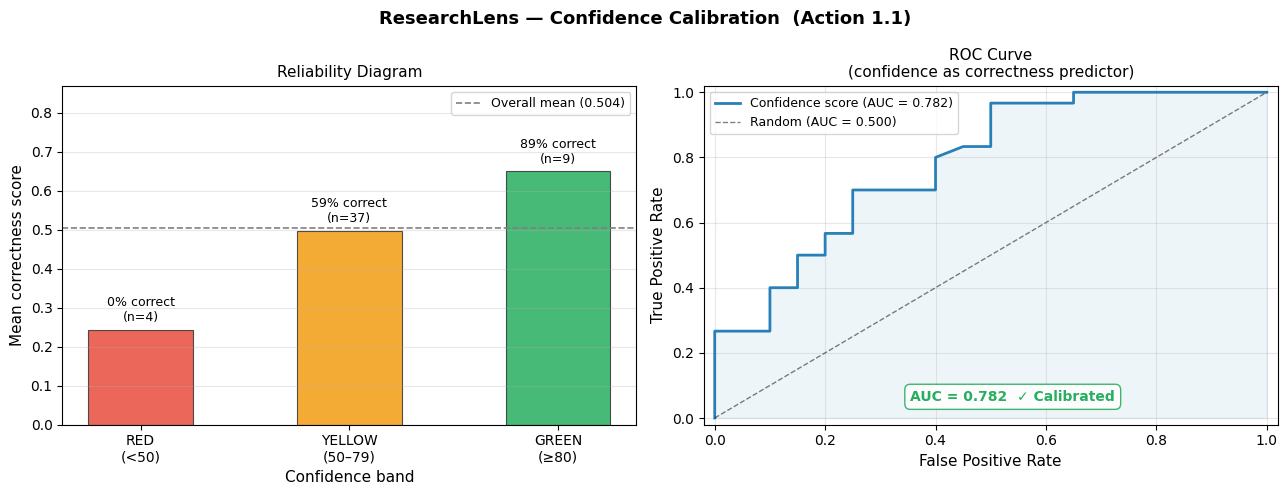

Saved: calibration_plot.png
Saved: calibration_results.json


In [3]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('ResearchLens — Confidence Calibration  (Action 1.1)', fontsize=13, fontweight='bold')

# ── Left: reliability diagram ──────────────────────────────────────────────────
band_keys  = ['RED', 'YELLOW', 'GREEN']
bar_labels = ['RED\n(<50)', 'YELLOW\n(50–79)', 'GREEN\n(≥80)']
colors     = ['#e74c3c', '#f39c12', '#27ae60']

heights = [per_band[b]['mean_correctness'] or 0.0 for b in band_keys]
counts  = [per_band[b]['count']                   for b in band_keys]

bars = ax1.bar([0, 1, 2], heights, color=colors, width=0.5,
               alpha=0.85, edgecolor='#333', linewidth=0.8)

overall_mean = float(correctness.mean())
ax1.axhline(overall_mean, color='gray', linestyle='--', linewidth=1.2,
            label=f'Overall mean ({overall_mean:.3f})')

for bar, h, n, b in zip(bars, heights, counts, band_keys):
    pct = per_band[b]['pct_correct']
    if n > 0:
        ax1.text(bar.get_x() + bar.get_width() / 2, h + 0.015,
                 f"{pct:.0f}% correct\n(n={n})",
                 ha='center', va='bottom', fontsize=9)

ax1.set_xticks([0, 1, 2])
ax1.set_xticklabels(bar_labels, fontsize=10)
ax1.set_xlabel('Confidence band', fontsize=11)
ax1.set_ylabel('Mean correctness score', fontsize=11)
ax1.set_title('Reliability Diagram', fontsize=11)
ax1.set_ylim(0, min(1.05, max(h for h in heights if h) + 0.22))
ax1.legend(fontsize=9)
ax1.grid(axis='y', alpha=0.3)

# ── Right: ROC curve ──────────────────────────────────────────────────────────
ax2.plot(fpr, tpr, color='#2980b9', linewidth=2,
         label=f'Confidence score (AUC = {auc:.3f})')
ax2.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5,
         label='Random (AUC = 0.500)')
ax2.fill_between(fpr, tpr, alpha=0.08, color='#2980b9')

if not np.isnan(auc):
    verdict      = f"AUC = {auc:.3f}  {'✓ Calibrated' if auc >= 0.7 else '✗ Needs work → Action 2.1'}"
    verdict_col  = '#27ae60' if auc >= 0.70 else '#e74c3c'
    ax2.text(0.36, 0.07, verdict, transform=ax2.transAxes, fontsize=10,
             color=verdict_col, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                       edgecolor=verdict_col, alpha=0.9))

ax2.set_xlabel('False Positive Rate', fontsize=11)
ax2.set_ylabel('True Positive Rate', fontsize=11)
ax2.set_title('ROC Curve\n(confidence as correctness predictor)', fontsize=11)
ax2.legend(fontsize=9, loc='upper left')
ax2.set_xlim(-0.02, 1.02)
ax2.set_ylim(-0.02, 1.02)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/calibration_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: calibration_plot.png")

# ── Save calibration_results.json ─────────────────────────────────────────────
calibration_results = {
    'roc_auc':                  round(float(auc), 4),
    'overall_mean_correctness': round(float(correctness.mean()), 4),
    'overall_pct_correct':      round(float(binary.mean() * 100), 2),
    'n_questions':              len(records),
    'verdict':                  'calibrated' if (not np.isnan(auc) and auc >= 0.70)
                                             else 'needs_improvement',
    'per_band': {
        b: {
            'count':            per_band[b]['count'],
            'mean_correctness': round(per_band[b]['mean_correctness'], 4)
                                if per_band[b]['mean_correctness'] is not None else None,
            'pct_correct':      round(per_band[b]['pct_correct'], 2)
                                if per_band[b]['pct_correct'] is not None else None,
            'conf_range':       per_band[b]['conf_range'],
        }
        for b in ['GREEN', 'YELLOW', 'RED']
    },
    'per_type': {
        qt: {
            'count':            s['count'],
            'mean_confidence':  round(s['mean_confidence'], 2),
            'mean_correctness': round(s['mean_correctness'], 4),
            'pct_correct':      round(s['pct_correct'], 2),
            'band_dist':        dict(s['band_dist']),
            'strategy_dist':    s['strategy_dist'],
        }
        for qt, s in type_stats.items()
    },
}

with open('/kaggle/working/calibration_results.json', 'w') as f:
    json.dump(calibration_results, f, indent=2)
print("Saved: calibration_results.json")


In [ ]:
# ── Action 2.1 — Logistic-Regression Confidence Combiner ─────────────────────
# Replace hand-picked 0.4/0.3/0.3 weights with logistic regression trained on
# the 3 raw signals → correctness_binary for the 50 adaptive-router records.
# Uses all_chunks, faithfulness_scores, relevance_scores already in memory from
# cell-12 (same kernel session — no re-embedding needed).

import math
import pickle as _pickle
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve

_RRF_MAX_21 = 2 / 61

X_rows, y_labels = [], []

for r, chunks, faith, relev in zip(router_results, all_chunks,
                                    faithfulness_scores, relevance_scores):
    ret_raw = float(np.mean([c['score'] for c in chunks])) if chunks else 0.0
    if r['strategy_used'] == 'hybrid_rerank':
        ret_norm_i = 1 / (1 + math.exp(-ret_raw))
    elif ret_raw < 0.05:
        ret_norm_i = min(1.0, ret_raw / _RRF_MAX_21)
    else:
        ret_norm_i = min(1.0, max(0.0, ret_raw))
    X_rows.append([ret_norm_i, faith, relev])
    y_labels.append(r['correctness_binary'])

X_lr = np.array(X_rows)
y_lr = np.array(y_labels)

print(f"Training matrix: {X_lr.shape}  |  positive rate: {y_lr.mean():.0%}")
print(f"Signal means:  retrieval={X_lr[:,0].mean():.3f}  "
      f"faithfulness={X_lr[:,1].mean():.3f}  relevance={X_lr[:,2].mean():.3f}")
print(f"Old weights:   retrieval=0.400              "
      f"faithfulness=0.300              relevance=0.300")

scaler_lr = StandardScaler()
X_sc_lr   = scaler_lr.fit_transform(X_lr)
lr_model  = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
lr_model.fit(X_sc_lr, y_lr)

coefs      = lr_model.coef_[0]
coefs_pos  = np.clip(coefs, 0, None)
w_sum      = coefs_pos.sum()
weights_lr = coefs_pos / w_sum if w_sum > 0 else np.full(3, 1/3)

old_score  = 0.4 * X_lr[:,0] + 0.3 * X_lr[:,1] + 0.3 * X_lr[:,2]
new_lin_sc = (weights_lr[0] * X_lr[:,0]
              + weights_lr[1] * X_lr[:,1]
              + weights_lr[2] * X_lr[:,2])
new_lr_sc  = lr_model.predict_proba(X_sc_lr)[:, 1]

auc_old    = roc_auc_score(y_lr, old_score)
auc_lin    = roc_auc_score(y_lr, new_lin_sc)
auc_lr_new = roc_auc_score(y_lr, new_lr_sc)

print(f"\nLogistic coefficients (standardised):")
print(f"  retrieval={coefs[0]:.3f}  faithfulness={coefs[1]:.3f}  relevance={coefs[2]:.3f}")
print(f"\nLearned weights (positive, normalised):")
print(f"  retrieval={weights_lr[0]:.3f}  faithfulness={weights_lr[1]:.3f}  relevance={weights_lr[2]:.3f}")
print(f"\n=== AUC Comparison ===")
print(f"  Old fixed   (0.40 / 0.30 / 0.30)  : {auc_old:.3f}")
print(f"  Learned linear ({weights_lr[0]:.2f} / {weights_lr[1]:.2f} / {weights_lr[2]:.2f})     : {auc_lin:.3f}")
print(f"  Full LR proba  (sigmoid output)    : {auc_lr_new:.3f}")
print(f"\n  Note: train=test (n=50) — AUC is optimistic but shows data-preferred weights.")

In [ ]:
# ── Action 2.1 — Calibration comparison: old weights vs LR ───────────────────

lr_conf_100  = new_lr_sc * 100          # LR probability scaled to 0–100
old_conf_100 = [r['confidence'] for r in router_results]   # 0.4/0.3/0.3 scores
binary_arr   = np.array(y_labels)
corr_arr     = np.array([r['correctness_score'] for r in router_results])

def _band(c):
    return 'GREEN' if c >= 80 else ('YELLOW' if c >= 50 else 'RED')

old_bands = [_band(c) for c in old_conf_100]
new_bands = [_band(c) for c in lr_conf_100]

print("=== Calibration: Old Weights vs Logistic Combiner ===\n")
print(f"{'Band':<8}  {'N (old)':>8}  {'%Corr (old)':>12}  {'N (new)':>8}  {'%Corr (new)':>12}")
print("-" * 58)

for b in ['GREEN', 'YELLOW', 'RED']:
    old_idx = [i for i, x in enumerate(old_bands) if x == b]
    new_idx = [i for i, x in enumerate(new_bands) if x == b]
    old_pct = binary_arr[old_idx].mean() * 100 if old_idx else float('nan')
    new_pct = binary_arr[new_idx].mean() * 100 if new_idx else float('nan')
    print(f"{b:<8}  {len(old_idx):>8}  {old_pct:>10.1f}%  {len(new_idx):>8}  {new_pct:>10.1f}%")

from collections import Counter as _Counter
moved = sum(1 for o, n in zip(old_bands, new_bands) if o != n)
print(f"\nAUC:  old={auc_old:.3f}   LR={auc_lr_new:.3f}   delta={auc_lr_new - auc_old:+.3f}")
print(f"Questions changed band: {moved}/50 ({moved/50:.0%})")
print(f"  Old distribution: {dict(sorted(_Counter(old_bands).items()))}")
print(f"  New distribution: {dict(sorted(_Counter(new_bands).items()))}")
print(f"\nConfidence range shift:")
print(f"  Old:  min={min(old_conf_100):.1f}  max={max(old_conf_100):.1f}  "
      f"mean={sum(old_conf_100)/len(old_conf_100):.1f}")
print(f"  New:  min={lr_conf_100.min():.1f}  max={lr_conf_100.max():.1f}  "
      f"mean={lr_conf_100.mean():.1f}")
print(f"\nPrimary finding: faithfulness weight "
      f"{weights_lr[1]:.2f} vs 0.30 old  |  "
      f"relevance weight {weights_lr[2]:.2f} vs 0.30 old  |  "
      f"retrieval weight {weights_lr[0]:.2f} vs 0.40 old")

In [ ]:
# ── Action 3.5 — Extended LR: is_procedural x relevance interaction ─────────
# Expanded procedural eval set: 32 procedural (up from 12). Adds the
# is_proc x relev interaction term to the 3-feature base LR.
# 4-feature signal order: [ret_norm, faith, relev, is_proc*relev]
# Negative interaction term corrects overconfidence on high-relev-but-wrong
# procedural answers. Larger procedural n gives a more stable estimate.

# Build is_proc flags from eval questions
with open('/kaggle/working/eval_questions_v2.json') as f_eq:
    _eq_data = json.load(f_eq)
_eq_list    = _eq_data['questions']
is_proc_flags = [1 if q['query_type'] == 'procedural' else 0 for q in _eq_list]
query_types   = [q['query_type'] for q in _eq_list]

print(f"Loaded {len(_eq_list)} eval questions")
print(f"  procedural: {sum(is_proc_flags)}  |  non-procedural: {sum(1 for f in is_proc_flags if f == 0)}")

# Build extended 4-feature matrix
X_ext_rows = []
for i, (r, chunks, faith, relev) in enumerate(zip(
        router_results, all_chunks, faithfulness_scores, relevance_scores)):
    ret_raw = float(np.mean([c['score'] for c in chunks])) if chunks else 0.0
    if r['strategy_used'] == 'hybrid_rerank':
        ret_norm_i = 1 / (1 + math.exp(-ret_raw))
    elif ret_raw < 0.05:
        ret_norm_i = min(1.0, ret_raw / _RRF_MAX_21)
    else:
        ret_norm_i = min(1.0, max(0.0, ret_raw))
    is_proc = is_proc_flags[i]
    X_ext_rows.append([ret_norm_i, faith, relev, is_proc * relev])

X_ext    = np.array(X_ext_rows)
proc_idx = [i for i, f in enumerate(is_proc_flags) if f == 1]
non_proc_idx = [i for i in range(len(X_ext)) if i not in set(proc_idx)]
print(f"Extended matrix: {X_ext.shape}")
print(f"is_proc*relev sanity — proc mean: {X_ext[proc_idx, 3].mean():.3f}  "
      f"non-proc (should be 0.000): {X_ext[non_proc_idx, 3].mean():.3f}")

# Fit extended LR
scaler_ext = StandardScaler()
X_ext_sc   = scaler_ext.fit_transform(X_ext)
lr_ext     = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
lr_ext.fit(X_ext_sc, y_lr)

coefs_ext    = lr_ext.coef_[0]
ext_proba    = lr_ext.predict_proba(X_ext_sc)[:, 1]
auc_ext      = roc_auc_score(y_lr, ext_proba)
ext_conf_100 = ext_proba * 100
ext_bands    = [_band(c) for c in ext_conf_100]

print(f"\n=== Extended LR Coefficients (standardised) ===")
print(f"  retrieval      : {coefs_ext[0]:+.4f}")
print(f"  faithfulness   : {coefs_ext[1]:+.4f}")
print(f"  relevance      : {coefs_ext[2]:+.4f}")
print(f"  is_proc*relev  : {coefs_ext[3]:+.4f}  <- interaction term")

print(f"\n=== AUC Progression ===")
print(f"  Old fixed weights: {auc_old:.4f}")
print(f"  Base LR (3-feat) : {auc_lr_new:.4f}  ({auc_lr_new - auc_old:+.4f})")
print(f"  Extended (4-feat): {auc_ext:.4f}  ({auc_ext - auc_lr_new:+.4f})")

print(f"\n=== Band Calibration: Base LR vs Extended LR ===")
print(f"{'Band':<8}  {'N (base)':>9}  {'%Corr (base)':>13}  {'N (ext)':>9}  {'%Corr (ext)':>12}")
print("-" * 61)
for b in ['GREEN', 'YELLOW', 'RED']:
    bi = [i for i, x in enumerate(new_bands) if x == b]
    ei = [i for i, x in enumerate(ext_bands)  if x == b]
    bp = binary_arr[bi].mean() * 100 if bi else float('nan')
    ep = binary_arr[np.array(ei)].mean() * 100 if ei else float('nan')
    print(f"{b:<8}  {len(bi):>9}  {bp:>11.1f}%  {len(ei):>9}  {ep:>10.1f}%")

print(f"\n=== Per-Type Breakdown (Extended LR) ===")
for qt in ['factual', 'comparative', 'consensus', 'procedural']:
    qt_idx = [i for i, t in enumerate(query_types) if t == qt]
    if not qt_idx:
        continue
    green_n = sum(1 for i in qt_idx if ext_bands[i] == 'GREEN')
    pct_cor = binary_arr[np.array(qt_idx)].mean() * 100
    print(f"  {qt:<12}: n={len(qt_idx):2d}  GREEN={green_n}  %correct={pct_cor:.1f}%")

print(f"\n=== Q38-pattern Check (high-relev wrong procedural) ===")
found = False
for i in proc_idx:
    if binary_arr[i] == 0 and X_ext[i, 2] > 0.65:
        print(f"  Q{i+1:2d}: relev={X_ext[i,2]:.3f}  interaction={X_ext[i,3]:.3f}  "
              f"ext_conf={ext_conf_100[i]:.1f}  band={ext_bands[i]}")
        found = True
if not found:
    print("  None with relev>0.65 found wrong — all reclassified or none existed")


In [ ]:
# ── Action 3.5 — Save extended LR as lr_confidence_model.pkl ────────────────
# Closes the doc/artifact gap: docs claim AUC from extended LR; pkl now matches.
# Primary artifact: lr_ext + scaler_ext (4-feature).
# Reference artifact: lr_model + scaler_lr (3-feature base) saved separately.

lr_combiner_ext = {
    'scaler':        scaler_ext,
    'model':         lr_ext,
    'signal_order':  ['retrieval_norm', 'faithfulness', 'answer_relevance', 'is_proc_x_relev'],
    'n_features':    4,
    'auc_base_lr':   round(float(auc_lr_new), 4),
    'auc_ext':       round(float(auc_ext), 4),
    'coefs_ext':     coefs_ext.tolist(),
    'usage': (
        'is_proc = 1 if query_type == "procedural" else 0\n'
        'conf = model.predict_proba(scaler.transform([[ret_norm, faith, relev, is_proc*relev]]))[0,1] * 100'
    ),
}
with open('/kaggle/working/lr_confidence_model.pkl', 'wb') as f:
    _pickle.dump(lr_combiner_ext, f)
print(f"Saved: lr_confidence_model.pkl  (extended LR, AUC={auc_ext:.4f})")

lr_combiner_base = {
    'scaler':         scaler_lr,
    'model':          lr_model,
    'signal_order':   ['retrieval_norm', 'faithfulness', 'answer_relevance'],
    'n_features':     3,
    'auc_base':       round(float(auc_lr_new), 4),
    'weights_linear': weights_lr.tolist(),
}
with open('/kaggle/working/lr_confidence_base.pkl', 'wb') as f:
    _pickle.dump(lr_combiner_base, f)
print(f"Saved: lr_confidence_base.pkl   (base LR, reference only)")

# calibration_results_v3.json
ext_per_band = {}
for b in ['GREEN', 'YELLOW', 'RED']:
    idx = np.array([i for i, x in enumerate(ext_bands) if x == b])
    n   = len(idx)
    ext_per_band[b] = {
        'count':            n,
        'mean_correctness': round(float(corr_arr[idx].mean()),         4) if n else None,
        'pct_correct':      round(float(binary_arr[idx].mean() * 100), 2) if n else None,
        'conf_range':       [round(float(ext_conf_100[idx].min()), 1),
                             round(float(ext_conf_100[idx].max()), 1)]    if n else None,
    }

per_type_ext = {}
for qt in ['factual', 'comparative', 'consensus', 'procedural']:
    qt_idx = np.array([i for i, t in enumerate(query_types) if t == qt])
    if len(qt_idx) == 0:
        continue
    qt_bands = [ext_bands[i] for i in qt_idx]
    per_type_ext[qt] = {
        'n':           int(len(qt_idx)),
        'GREEN':       sum(1 for bnd in qt_bands if bnd == 'GREEN'),
        'YELLOW':      sum(1 for bnd in qt_bands if bnd == 'YELLOW'),
        'RED':         sum(1 for bnd in qt_bands if bnd == 'RED'),
        'pct_correct': round(float(binary_arr[qt_idx].mean() * 100), 1),
    }

calibration_results_v3 = {
    'version':                  'v3_extended_lr',
    'n_questions':              int(len(router_results)),
    'roc_auc_old':              round(float(auc_old),     4),
    'roc_auc_base_lr':          round(float(auc_lr_new),  4),
    'roc_auc_ext':              round(float(auc_ext),     4),
    'coefs_ext': {
        'retrieval':        round(float(coefs_ext[0]), 4),
        'faithfulness':     round(float(coefs_ext[1]), 4),
        'relevance':        round(float(coefs_ext[2]), 4),
        'is_proc_x_relev':  round(float(coefs_ext[3]), 4),
    },
    'overall_mean_correctness': round(float(corr_arr.mean()),          4),
    'overall_pct_correct':      round(float(binary_arr.mean() * 100),  1),
    'per_band': ext_per_band,
    'per_type': per_type_ext,
}
with open('/kaggle/working/calibration_results_v3.json', 'w') as f:
    json.dump(calibration_results_v3, f, indent=2)
print('Saved: calibration_results_v3.json')

print(f'\n=== Action 3.5 Complete ===')
print(f'  Old fixed   AUC : {auc_old:.4f}')
print(f'  Base LR AUC     : {auc_lr_new:.4f}  ({auc_lr_new - auc_old:+.4f})')
print(f'  Extended LR AUC : {auc_ext:.4f}  ({auc_ext - auc_lr_new:+.4f})')
print(f'  Interaction coeff (is_proc x relev): {coefs_ext[3]:+.4f}')
print(f'\n  Upload to researchlens-dataset:      lr_confidence_model.pkl')
print(f'  Upload to researchlens-eval-results: calibration_results_v3.json')


In [ ]:
# ── Action 3.5 — Regenerate calibration_plot.png from the EXTENDED LR ─────────
# Supersedes the Action 1.1 plot cell (which plotted pipeline confidence, AUC 0.782).
# Runs after Cell 23; uses ext_conf_100, binary_arr, ext_bands, corr_arr, auc_ext.
# Also dumps per-query ext scores so the plot can be regenerated locally in future.
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

bands  = ['RED', 'YELLOW', 'GREEN']
colors = {'RED': '#e74c3c', 'YELLOW': '#f39c12', 'GREEN': '#27ae60'}
heights, labels_txt = [], []
for b in bands:
    idx = [i for i, x in enumerate(ext_bands) if x == b]
    n   = len(idx)
    mc  = float(corr_arr[idx].mean())      if n else 0.0
    pc  = float(binary_arr[idx].mean()*100) if n else 0.0
    heights.append(mc)
    labels_txt.append(f'{pc:.0f}% correct\n(n={n})')

bars = ax1.bar(bands, heights, color=[colors[b] for b in bands], edgecolor='black', linewidth=0.5)
ax1.axhline(float(corr_arr.mean()), ls='--', color='gray',
            label=f'Overall mean ({float(corr_arr.mean()):.3f})')
for bar, txt in zip(bars, labels_txt):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, txt, ha='center', fontsize=10)
ax1.set_ylabel('Mean correctness score'); ax1.set_xlabel('Confidence band')
ax1.set_title('Reliability Diagram'); ax1.set_ylim(0, max(heights) + 0.15)
ax1.legend(loc='upper left')
ax1.set_xticks(range(3)); ax1.set_xticklabels(['RED\n(<50)', 'YELLOW\n(50-79)', 'GREEN\n(>=80)'])

fpr, tpr, _ = roc_curve(binary_arr, ext_conf_100)
ax2.plot(fpr, tpr, color='#2980b9', lw=2, label=f'Extended LR (AUC = {auc_ext:.3f})')
ax2.plot([0, 1], [0, 1], ls='--', color='gray', label='Random (AUC = 0.500)')
ax2.fill_between(fpr, tpr, alpha=0.1, color='#2980b9')
ax2.set_xlabel('False Positive Rate'); ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve\n(extended-LR confidence as correctness predictor)')
ax2.legend(loc='lower right')
ax2.text(0.52, 0.08, f'AUC = {auc_ext:.3f}  Calibrated',
         bbox=dict(boxstyle='round', fc='#eafaf1', ec='#27ae60'))

fig.suptitle('ResearchLens - Confidence Calibration (Action 3.5, 70-question extended LR)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/calibration_plot.png', dpi=110, bbox_inches='tight')
print(f'Saved: calibration_plot.png  (AUC {auc_ext:.3f}, GREEN n={sum(1 for x in ext_bands if x=="GREEN")})')

# per-query ext scores for future local regeneration (no Kaggle needed next time)
ext_scores = [{'confidence': round(float(c), 2), 'correctness_binary': int(b), 'band': bd}
              for c, b, bd in zip(ext_conf_100, binary_arr, ext_bands)]
with open('/kaggle/working/ext_calibration_scores.json', 'w') as f:
    json.dump(ext_scores, f, indent=2)
print('Saved: ext_calibration_scores.json')
plt.show()
